In [22]:
# If needed, run this once:
# !pip install pandas scipy statsmodels openpyxl matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests

# =========================
# 1. Load Excel file
# =========================

file_path = "To be analyze.xlsx"   # change path if needed
sheet_name = "Sheet1"

# Block 1: A:F, first row has treatment names
count_wide = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    usecols="A:F",
    header=0,
    nrows=4
)

# Block 2: Diameter is in H:M.
# Row 1 says "Diameter", row 2 has treatment names, so header=1
diameter_wide = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    usecols="H:M",
    header=1
).dropna(how="all")

# Block 3: Survivability is in Q:U, but P contains AVG/STD labels.
# We use P:U so we can remove AVG and STD rows.
surv_raw = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    usecols="P:U",
    header=1
)

# Drop rows where all treatment values are empty
surv_raw = surv_raw.dropna(how="all")

# First column is the AVG/STD label column
label_col = surv_raw.columns[0]

# Keep only raw data rows, not AVG/STD rows
survivability_wide = surv_raw[surv_raw[label_col].isna()].drop(columns=[label_col])


# =========================
# 2. Helper functions
# =========================

def clean_wide_data(wide_df):
    """
    Cleans wide-format treatment data.
    Each column should be one treatment group.
    Each row should be one replicate.
    """
    df = wide_df.copy()
    
    # Clean column names
    df.columns = [str(c).strip().replace("PEG8K", "PEG 8K") for c in df.columns]
    
    # Convert all values to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # Drop rows and columns that are completely empty
    df = df.dropna(how="all")
    df = df.dropna(axis=1, how="all")
    
    return df


def wide_to_long(wide_df, outcome_name):
    """
    Converts wide-format data into long format for ANOVA.
    """
    df = clean_wide_data(wide_df)
    
    long_df = df.melt(
        var_name="Treatment",
        value_name="Value"
    ).dropna()
    
    long_df["Outcome"] = outcome_name
    return long_df


def run_anova_analysis(wide_df, outcome_name, control_name="Before", higher_is_better=True):
    """
    Runs:
    1. One-way ANOVA
    2. Treatment vs control comparisons
    3. Tukey HSD all-pair treatment comparisons
    4. Finds best treatment by mean
    """
    
    print("=" * 80)
    print(f"ANALYSIS FOR: {outcome_name}")
    print("=" * 80)
    
    long_df = wide_to_long(wide_df, outcome_name)
    
    # -------------------------
    # Summary statistics
    # -------------------------
    summary = (
        long_df
        .groupby("Treatment")["Value"]
        .agg(["count", "mean", "std", "median", "min", "max"])
        .sort_values("mean", ascending=not higher_is_better)
    )
    
    print("\nSummary statistics:")
    display(summary)
    
    # -------------------------
    # One-way ANOVA
    # -------------------------
    groups = [
        group["Value"].values
        for name, group in long_df.groupby("Treatment")
    ]
    
    f_stat, p_value = stats.f_oneway(*groups)
    
    print("\nOne-way ANOVA:")
    print(f"F-statistic = {f_stat:.4f}")
    print(f"p-value     = {p_value:.6f}")
    
    if p_value < 0.05:
        print("Result: Significant difference across groups.")
    else:
        print("Result: No statistically significant difference across groups.")
    
    # Statsmodels ANOVA table
    model = ols("Value ~ C(Treatment)", data=long_df).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # Effect size: eta squared
    ss_treatment = anova_table.loc["C(Treatment)", "sum_sq"]
    ss_total = ss_treatment + anova_table.loc["Residual", "sum_sq"]
    eta_squared = ss_treatment / ss_total
    
    print(f"\nEta squared effect size = {eta_squared:.4f}")
    print("Rule of thumb: 0.01 small, 0.06 medium, 0.14 large")
    
    print("\nANOVA table:")
    display(anova_table)
    
    # -------------------------
    # Treatment vs Control
    # -------------------------
    control_results = None
    
    if control_name in long_df["Treatment"].unique():
        control_values = long_df.loc[
            long_df["Treatment"] == control_name, "Value"
        ].values
        
        results = []
        
        for treatment in long_df["Treatment"].unique():
            if treatment == control_name:
                continue
            
            treatment_values = long_df.loc[
                long_df["Treatment"] == treatment, "Value"
            ].values
            
            t_stat, p_raw = stats.ttest_ind(
                treatment_values,
                control_values,
                equal_var=False
            )
            
            mean_control = np.mean(control_values)
            mean_treatment = np.mean(treatment_values)
            mean_diff = mean_treatment - mean_control
            
            results.append({
                "Treatment": treatment,
                "Control": control_name,
                "Treatment Mean": mean_treatment,
                "Control Mean": mean_control,
                "Mean Difference": mean_diff,
                "t-stat": t_stat,
                "raw p-value": p_raw
            })
        
        control_results = pd.DataFrame(results)
        
        # Adjust p-values for multiple comparisons using Holm correction
        reject, p_adj, _, _ = multipletests(
            control_results["raw p-value"],
            alpha=0.05,
            method="holm"
        )
        
        control_results["adjusted p-value"] = p_adj
        control_results["Significant after Holm correction"] = reject
        
        print(f"\nTreatment vs Control comparisons: control = {control_name}")
        display(control_results.sort_values("adjusted p-value"))
    
    else:
        print(f"\nNo control group named '{control_name}' found for this outcome.")
        print("Skipping treatment-vs-control comparison.")
    
    # -------------------------
    # Tukey HSD: all pairwise treatment comparisons
    # -------------------------
    tukey = pairwise_tukeyhsd(
        endog=long_df["Value"],
        groups=long_df["Treatment"],
        alpha=0.05
    )
    
    tukey_df = pd.DataFrame(
        data=tukey.summary().data[1:],
        columns=tukey.summary().data[0]
    )
    
    print("\nTukey HSD: all treatment-vs-treatment comparisons")
    display(tukey_df)
    
    # -------------------------
    # Best treatment by mean
    # -------------------------
    if higher_is_better:
        best_treatment = summary["mean"].idxmax()
        best_mean = summary.loc[best_treatment, "mean"]
        print(f"\nBest treatment by highest mean: {best_treatment} with mean = {best_mean:.4f}")
    else:
        best_treatment = summary["mean"].idxmin()
        best_mean = summary.loc[best_treatment, "mean"]
        print(f"\nBest treatment by lowest mean: {best_treatment} with mean = {best_mean:.4f}")
    
    # -------------------------
    # Plot means with error bars
    # -------------------------
    plot_df = summary.reset_index()
    
    plt.figure(figsize=(9, 5))
    plt.bar(plot_df["Treatment"], plot_df["mean"], yerr=plot_df["std"], capsize=5)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(outcome_name)
    plt.title(f"{outcome_name}: Mean by Treatment")
    plt.tight_layout()
    plt.show()
    
    return {
        "long_data": long_df,
        "summary": summary,
        "anova_table": anova_table,
        "control_comparisons": control_results,
        "tukey": tukey_df,
        "best_treatment": best_treatment
    }


# =========================
# 3. Run analyses
# =========================



ANALYSIS FOR: Count / Concentration

Summary statistics:


,count,mean,std,median,min,max
Treatment,,,,,,
Before,4,1.526786e+08,1.105606e+07,150000000.0,1.428571e+08,1.678571e+08
PEG 8K,4,1.256250e+08,2.239559e+07,126250000.0,1.000000e+08,1.500000e+08
PEG 20K,4,1.100000e+08,3.259601e+07,108750000.0,7.750000e+07,1.450000e+08
Trehalose,4,1.068750e+08,3.670689e+07,100000000.0,7.250000e+07,1.550000e+08
PEG 4K,4,9.875000e+07,2.240722e+07,95000000.0,7.750000e+07,1.275000e+08
PEG 1.5K,4,9.500000e+07,1.457738e+07,96250000.0,8.000000e+07,1.075000e+08



One-way ANOVA:
F-statistic = 2.9293
p-value     = 0.041684
Result: Significant difference across groups.

Eta squared effect size = 0.4486
Rule of thumb: 0.01 small, 0.06 medium, 0.14 large

ANOVA table:


,sum_sq,df,F,PR(>F)
C(Treatment),9.149809e+15,5.0,2.929284,0.041684
Residual,1.124483e+16,18.0,NaN,NaN



Treatment vs Control comparisons: control = Before


,Treatment,Control,Treatment Mean,Control Mean,Mean Difference,t-stat,raw p-value,adjusted p-value,Significant after Holm correction
1,PEG 1.5K,Before,95000000.0,1.526786e+08,-5.767857e+07,-6.305115,0.000972,0.004861,True
2,PEG 4K,Before,98750000.0,1.526786e+08,-5.392857e+07,-4.316636,0.010226,0.040906,True
0,Trehalose,Before,106875000.0,1.526786e+08,-4.580357e+07,-2.389599,0.083596,0.220967,False
3,PEG 8K,Before,125625000.0,1.526786e+08,-2.705357e+07,-2.166368,0.090262,0.220967,False
4,PEG 20K,Before,110000000.0,1.526786e+08,-4.267857e+07,-2.479871,0.073656,0.220967,False



Tukey HSD: all treatment-vs-treatment comparisons


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Before,PEG 1.5K,-5.767857e+07,0.0422,-1.138459e+08,-1.511220e+06,True
1,Before,PEG 20K,-4.267857e+07,0.2028,-9.884592e+07,1.348878e+07,False
2,Before,PEG 4K,-5.392857e+07,0.0641,-1.100959e+08,2.238780e+06,False
3,Before,PEG 8K,-2.705357e+07,0.6503,-8.322092e+07,2.911378e+07,False
4,Before,Trehalose,-4.580357e+07,0.1501,-1.019709e+08,1.036378e+07,False
5,PEG 1.5K,PEG 20K,1.500000e+07,0.9538,-4.116735e+07,7.116735e+07,False
6,PEG 1.5K,PEG 4K,3.750000e+06,0.9999,-5.241735e+07,5.991735e+07,False
7,PEG 1.5K,PEG 8K,3.062500e+07,0.5292,-2.554235e+07,8.679235e+07,False
8,PEG 1.5K,Trehalose,1.187500e+07,0.9829,-4.429235e+07,6.804235e+07,False
9,PEG 20K,PEG 4K,-1.125000e+07,0.9866,-6.741735e+07,4.491735e+07,False



Best treatment by highest mean: Before with mean = 152678571.4286


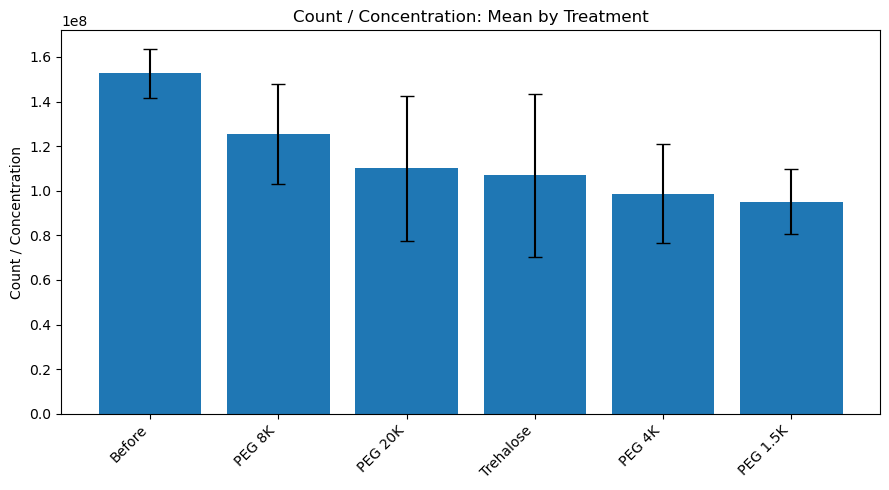

In [23]:
# For count / concentration data, higher is usually better.
count_results = run_anova_analysis(
    count_wide,
    outcome_name="Count / Concentration",
    control_name="Before",
    higher_is_better=True
)



ANALYSIS FOR: Diameter

Summary statistics:


,count,mean,std,median,min,max
Treatment,,,,,,
Trehalose,86,4.671160,1.377196,4.661449,1.783053,8.106523
PEG 20K,86,4.893669,1.929037,4.801303,1.926193,11.348208
PEG 1.5K,86,5.116008,1.949687,4.855602,1.627763,10.139666
PEG 8K,86,5.187847,1.689054,5.121769,2.183931,10.895493
PEG 4K,86,5.434095,2.401677,5.173281,1.627763,19.343098
Before,86,5.851253,1.963211,5.846550,1.627763,9.901680



One-way ANOVA:
F-statistic = 4.0503
p-value     = 0.001295
Result: Significant difference across groups.

Eta squared effect size = 0.0382
Rule of thumb: 0.01 small, 0.06 medium, 0.14 large

ANOVA table:


,sum_sq,df,F,PR(>F)
C(Treatment),73.899088,5.0,4.050323,0.001295
Residual,1861.013977,510.0,NaN,NaN



Treatment vs Control comparisons: control = Before


,Treatment,Control,Treatment Mean,Control Mean,Mean Difference,t-stat,raw p-value,adjusted p-value,Significant after Holm correction
0,Trehalose,Before,4.671160,5.851253,-1.180093,-4.563508,0.000010,0.000051,True
4,PEG 20K,Before,4.893669,5.851253,-0.957584,-3.226443,0.001504,0.006015,True
1,PEG 1.5K,Before,5.116008,5.851253,-0.735245,-2.464308,0.014722,0.044167,True
3,PEG 8K,Before,5.187847,5.851253,-0.663406,-2.375533,0.018662,0.044167,True
2,PEG 4K,Before,5.434095,5.851253,-0.417158,-1.247128,0.214134,0.214134,False



Tukey HSD: all treatment-vs-treatment comparisons


,group1,group2,meandiff,p-adj,lower,upper,reject
0,Before,PEG 1.5K,-0.7352,0.1191,-1.5686,0.0981,False
1,Before,PEG 20K,-0.9576,0.0137,-1.7909,-0.1243,True
2,Before,PEG 4K,-0.4172,0.7075,-1.2505,0.4162,False
3,Before,PEG 8K,-0.6634,0.2053,-1.4967,0.1699,False
4,Before,Trehalose,-1.1801,0.0008,-2.0134,-0.3468,True
5,PEG 1.5K,PEG 20K,-0.2223,0.9735,-1.0557,0.6110,False
6,PEG 1.5K,PEG 4K,0.3181,0.8846,-0.5152,1.1514,False
7,PEG 1.5K,PEG 8K,0.0718,0.9999,-0.7615,0.9052,False
8,PEG 1.5K,Trehalose,-0.4448,0.6469,-1.2782,0.3885,False
9,PEG 20K,PEG 4K,0.5404,0.4313,-0.2929,1.3737,False



Best treatment by lowest mean: Trehalose with mean = 4.6712


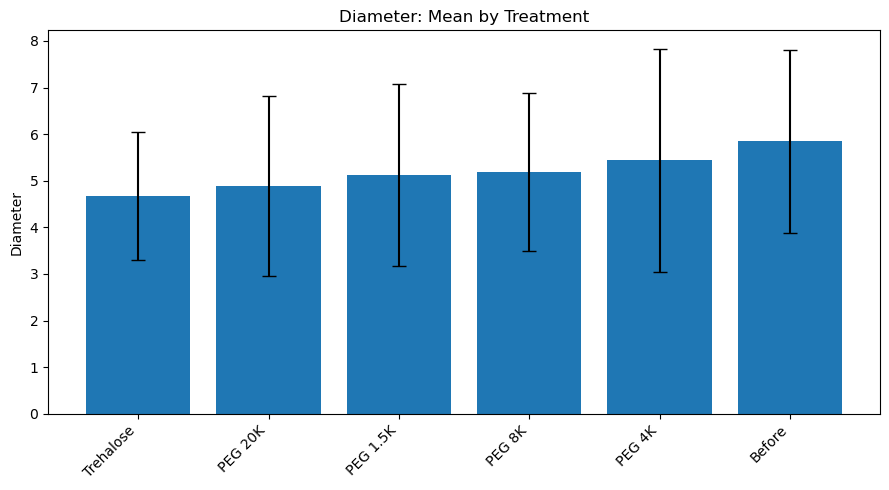

In [24]:
# For diameter, choose whether higher or lower is better.
# If smaller diameter is better, keep higher_is_better=False.
diameter_results = run_anova_analysis(
    diameter_wide,
    outcome_name="Diameter",
    control_name="Before",
    higher_is_better=False
)

ANALYSIS FOR: Survivability

Summary statistics:


,count,mean,std,median,min,max
Treatment,,,,,,
PEG 8K,4,82.280702,14.668457,82.690058,65.497076,98.245614
PEG 20K.1,4,72.046784,21.349435,71.228070,50.760234,94.970760
Trehalose.1,4,70.000000,24.041940,65.497076,47.485380,101.520468
PEG 4K.1,4,64.678363,14.676071,62.222222,50.760234,83.508772
PEG 1.5K.1,4,62.222222,9.547757,63.040936,52.397661,70.409357



One-way ANOVA:
F-statistic = 0.7827
p-value     = 0.553776
Result: No statistically significant difference across groups.

Eta squared effect size = 0.1727
Rule of thumb: 0.01 small, 0.06 medium, 0.14 large

ANOVA table:


,sum_sq,df,F,PR(>F)
C(Treatment),974.067918,4.0,0.782749,0.553776
Residual,4666.570911,15.0,NaN,NaN



No control group named 'Before' found for this outcome.
Skipping treatment-vs-control comparison.

Tukey HSD: all treatment-vs-treatment comparisons


,group1,group2,meandiff,p-adj,lower,upper,reject
0,PEG 1.5K.1,PEG 20K.1,9.8246,0.9303,-28.6882,48.3374,False
1,PEG 1.5K.1,PEG 4K.1,2.4561,0.9996,-36.0566,40.9689,False
2,PEG 1.5K.1,PEG 8K,20.0585,0.5146,-18.4543,58.5713,False
3,PEG 1.5K.1,Trehalose.1,7.7778,0.9689,-30.7350,46.2906,False
4,PEG 20K.1,PEG 4K.1,-7.3684,0.9744,-45.8812,31.1444,False
5,PEG 20K.1,PEG 8K,10.2339,0.9202,-28.2789,48.7467,False
6,PEG 20K.1,Trehalose.1,-2.0468,0.9998,-40.5596,36.4660,False
7,PEG 4K.1,PEG 8K,17.6023,0.6302,-20.9105,56.1151,False
8,PEG 4K.1,Trehalose.1,5.3216,0.9923,-33.1912,43.8344,False
9,PEG 8K,Trehalose.1,-12.2807,0.8581,-50.7935,26.2321,False



Best treatment by highest mean: PEG 8K with mean = 82.2807


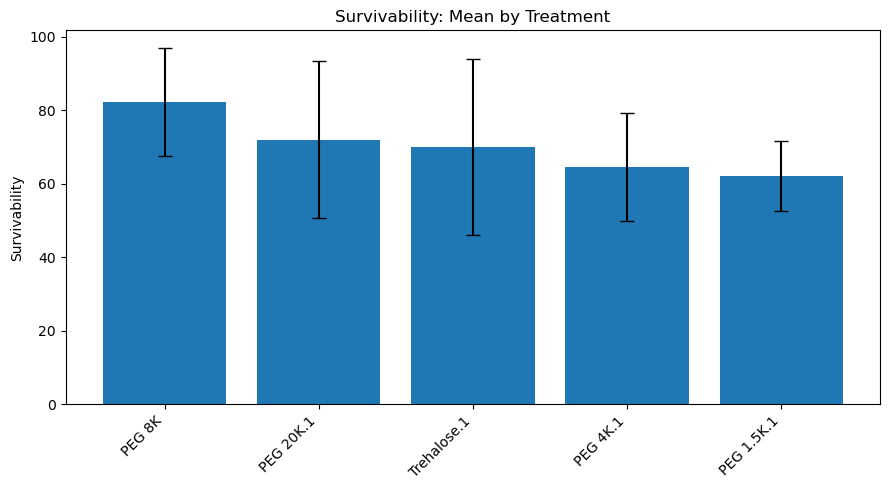

In [25]:
survivability_results = run_anova_analysis(
    survivability_wide,
    outcome_name="Survivability",
    control_name="Before",
    higher_is_better=True
)

ANALYSIS FOR: Survivability

Summary statistics:


,count,mean,std,median,min,max
Treatment,,,,,,
PEG 8K,4,82.280702,14.668457,82.690058,65.497076,98.245614
PEG 20K.1,4,72.046784,21.349435,71.228070,50.760234,94.970760
Trehalose.1,4,70.000000,24.041940,65.497076,47.485380,101.520468
PEG 4K.1,4,64.678363,14.676071,62.222222,50.760234,83.508772
PEG 1.5K.1,4,62.222222,9.547757,63.040936,52.397661,70.409357



One-way ANOVA:
F-statistic = 0.7827
p-value     = 0.553776
Result: No statistically significant difference across groups.

Eta squared effect size = 0.1727
Rule of thumb: 0.01 small, 0.06 medium, 0.14 large

ANOVA table:


,sum_sq,df,F,PR(>F)
C(Treatment),974.067918,4.0,0.782749,0.553776
Residual,4666.570911,15.0,NaN,NaN



No control group named 'Before' found for this outcome.
Skipping treatment-vs-control comparison.

Tukey HSD: all treatment-vs-treatment comparisons


,group1,group2,meandiff,p-adj,lower,upper,reject
0,PEG 1.5K.1,PEG 20K.1,9.8246,0.9303,-28.6882,48.3374,False
1,PEG 1.5K.1,PEG 4K.1,2.4561,0.9996,-36.0566,40.9689,False
2,PEG 1.5K.1,PEG 8K,20.0585,0.5146,-18.4543,58.5713,False
3,PEG 1.5K.1,Trehalose.1,7.7778,0.9689,-30.7350,46.2906,False
4,PEG 20K.1,PEG 4K.1,-7.3684,0.9744,-45.8812,31.1444,False
5,PEG 20K.1,PEG 8K,10.2339,0.9202,-28.2789,48.7467,False
6,PEG 20K.1,Trehalose.1,-2.0468,0.9998,-40.5596,36.4660,False
7,PEG 4K.1,PEG 8K,17.6023,0.6302,-20.9105,56.1151,False
8,PEG 4K.1,Trehalose.1,5.3216,0.9923,-33.1912,43.8344,False
9,PEG 8K,Trehalose.1,-12.2807,0.8581,-50.7935,26.2321,False



Best treatment by highest mean: PEG 8K with mean = 82.2807


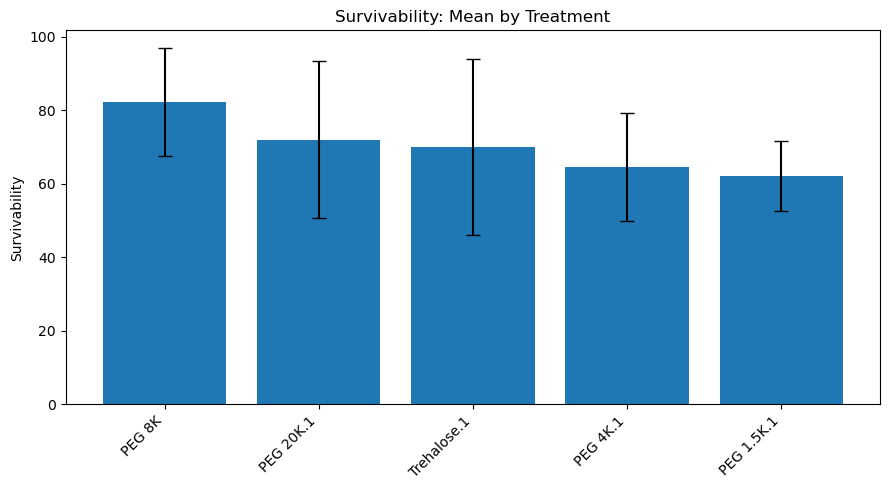

In [26]:
survivability_results = run_anova_analysis(
    survivability_wide,
    outcome_name="Survivability",
    control_name="Before",
    higher_is_better=True
)

In [32]:
count_results["summary"]
diameter_results["tukey"]
survivability_results["best_treatment"]

'PEG 8K'

In [33]:
# Significant treatment-vs-control results only
count_results["control_comparisons"].query("`Significant after Holm correction` == True")

,Treatment,Control,Treatment Mean,Control Mean,Mean Difference,t-stat,raw p-value,adjusted p-value,Significant after Holm correction
1,PEG 1.5K,Before,95000000.0,1.526786e+08,-5.767857e+07,-6.305115,0.000972,0.004861,True
2,PEG 4K,Before,98750000.0,1.526786e+08,-5.392857e+07,-4.316636,0.010226,0.040906,True


In [34]:
# Significant treatment-vs-treatment comparisons only
diameter_results["tukey"].query("reject == True")

,group1,group2,meandiff,p-adj,lower,upper,reject
1,Before,PEG 20K,-0.9576,0.0137,-1.7909,-0.1243,True
4,Before,Trehalose,-1.1801,0.0008,-2.0134,-0.3468,True
